# Assignment 9

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Activation

# *Part 1: Build the First Neural Network*

In [2]:
max_df = pd.read_csv('max.txt', sep='\t', header=None, names=['sequence', 'binding_affinity'])

In [3]:
def one_hot_encode_dna(sequence):
    encoding_map_1mer = {'A': [1, 0, 0, 0], 'C': [0, 1, 0, 0], 'G': [0, 0, 1, 0], 'T': [0, 0, 0, 1]}
    one_hot_encoded = []
    for nucleotide in sequence:
        one_hot_encoded.extend(encoding_map_1mer[nucleotide])

    return one_hot_encoded


def min_max_scale(binding_affinity):
    min_value = min(binding_affinity)
    max_value = max(binding_affinity)
    normalized_col = [(x - min_value) / (max_value - min_value) for x in binding_affinity]
    normalized_col = np.array(normalized_col)
    
    return normalized_col

In [4]:
seq = max_df['sequence'].to_list()
seq_encoded = np.array([one_hot_encode_dna(dna_seq) for dna_seq in seq])
binding_aff = max_df['binding_affinity'].to_list()
binding_aff_scaled = min_max_scale(binding_aff)

X_train, X_test, y_train, y_test = train_test_split(seq_encoded, binding_aff_scaled, test_size=0.2, random_state=24)

In [5]:
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(16))
model.add(Activation('sigmoid'))
model.add(Dense(1))
model.add(Activation('linear'))

model.compile(loss='mse', optimizer='adam', metrics=['mse'])
history = model.fit(X_train, y_train, batch_size=64, epochs=50, validation_data=(X_test, y_test), verbose=0)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_loss, train_mse = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_mse = model.evaluate(X_test, y_test, verbose=0)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print(f"Training MSE:", train_mse)
print(f"Testing MSE:", test_mse)
print(f"Training R-squared:", train_r2)
print(f"Testing R-squared:", test_r2)

215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 651us/step
Training MSE: 0.002562517300248146
Testing MSE: 0.00332584953866899
Training R-squared: 0.911363352369707
Testing R-squared: 0.8851747311021438


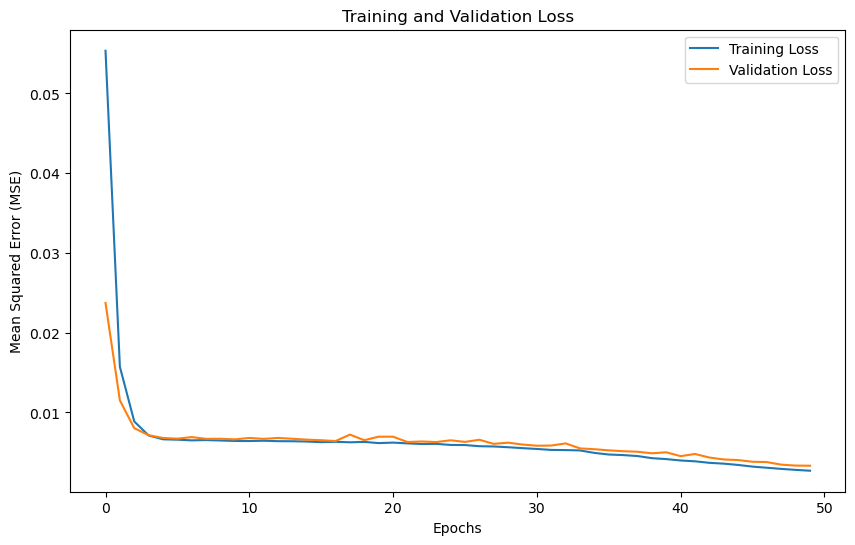

Validation R-Squared: 0.8851747311021438


In [6]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.show()

print('Validation R-Squared:', test_r2)

We can see that the r-squared of the baseline neural network is already solid. However, we would like to see the r-squared even closer to 1 by adjusting the model structure and some hyperparameter tuning. 

# *Part 2: Neural Network Comparison - hidden layer size*

In [7]:
def evaluate_nn(hidden_layer_size):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(hidden_layer_size))
    model.add(Activation('sigmoid'))
    model.add(Dense(1))
    model.add(Activation('linear'))
    
    model.compile(loss='mse', optimizer='adam', metrics=['mse'])
    history = model.fit(X_train, y_train, batch_size=64, epochs=50, validation_data=(X_test, y_test), verbose=0)
    
    test_pred = model.predict(X_test)
    test_r2 = r2_score(y_test, test_pred)
    
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.legend()
    plt.show()

    return test_r2

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


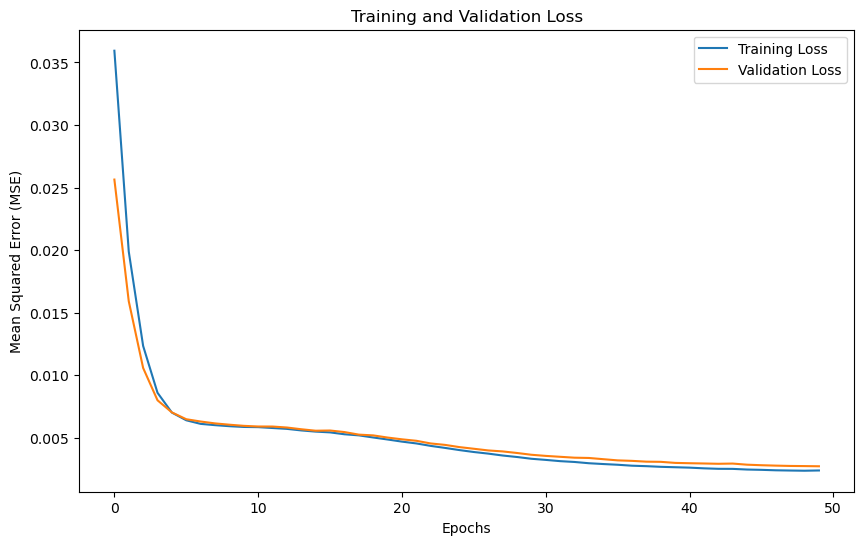

Validation R-Squared (Hidden Layer Size: 4): 0.9064759883759312
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


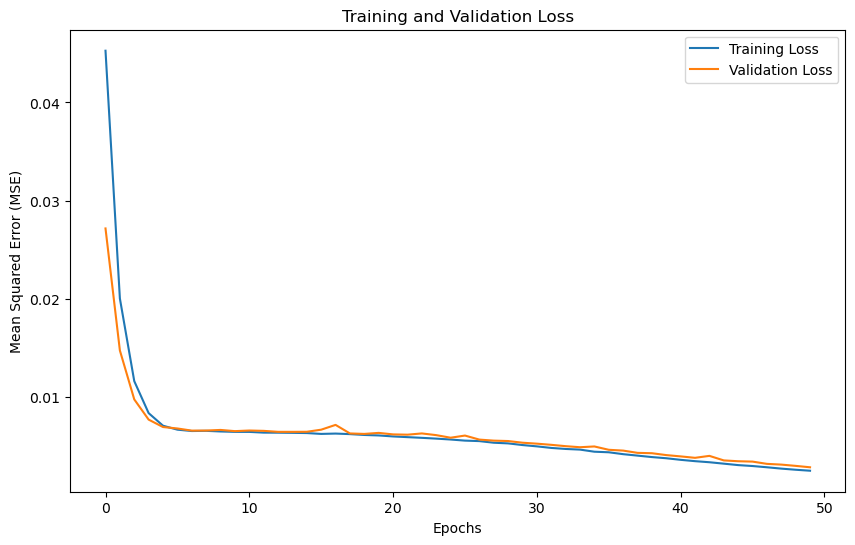

Validation R-Squared (Hidden Layer Size: 8): 0.9028672678844529
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


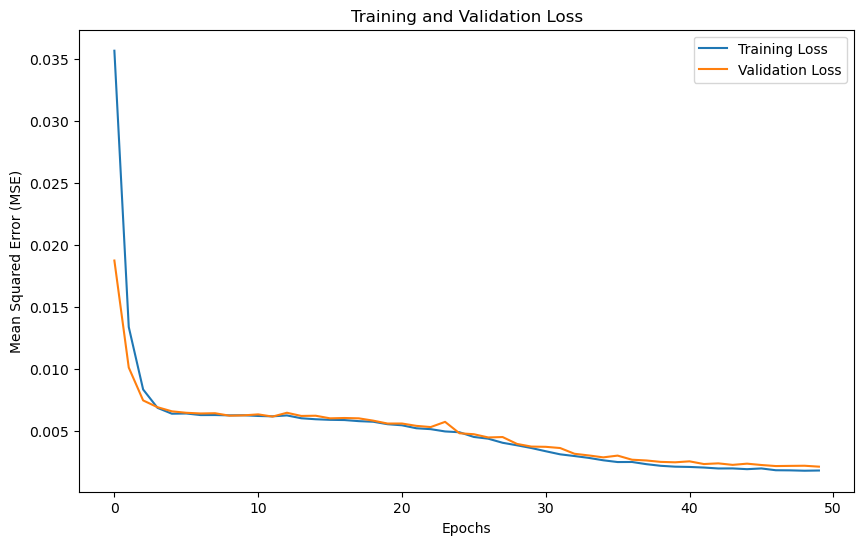

Validation R-Squared (Hidden Layer Size: 16): 0.9255268885562493
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


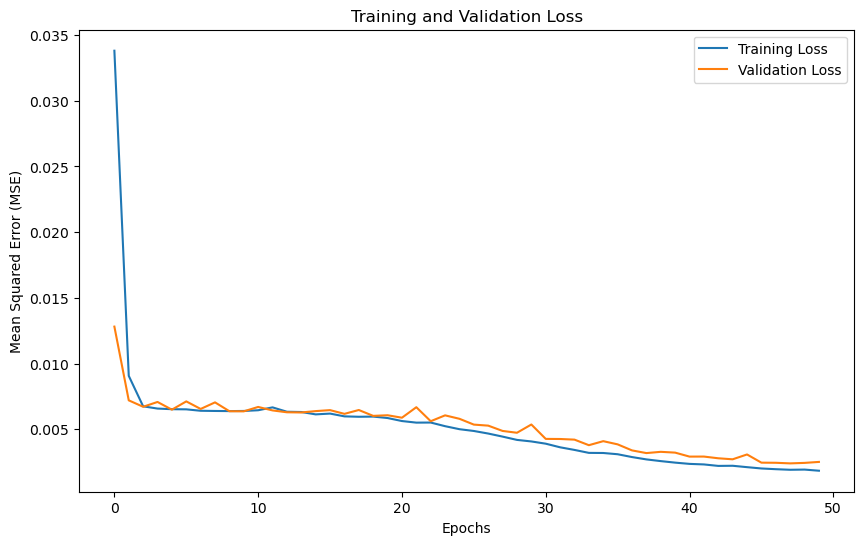

Validation R-Squared (Hidden Layer Size: 32): 0.9131251684533604
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 971us/step


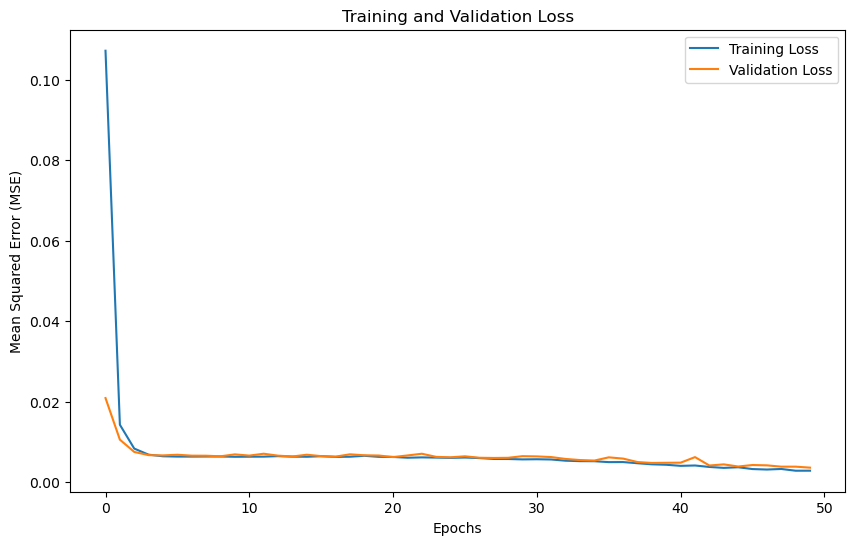

Validation R-Squared (Hidden Layer Size: 64): 0.8761026198834168
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


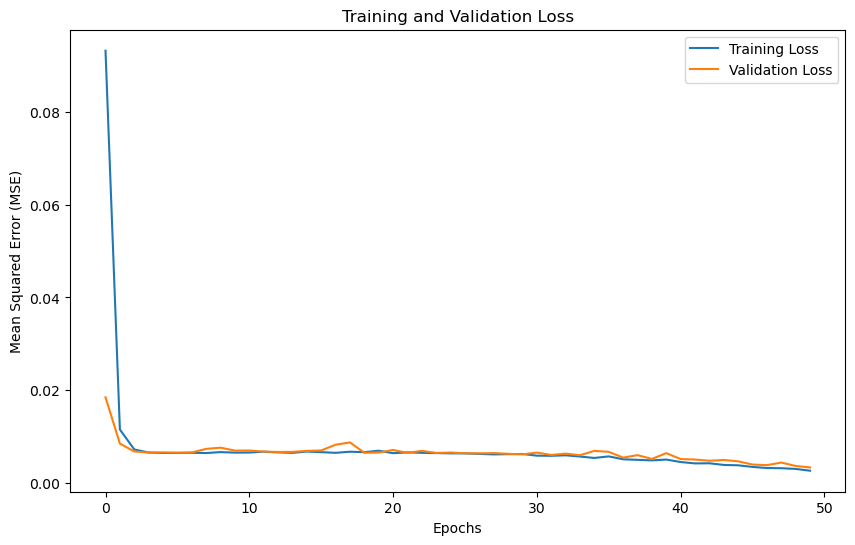

Validation R-Squared (Hidden Layer Size: 128): 0.8869714724547746


In [8]:
sizes = [4, 8, 16, 32, 64, 128]
r2_scores = []
for layer_size in sizes:
    config_r2 = evaluate_nn(layer_size)
    print(f'Validation R-Squared (Hidden Layer Size: {layer_size}):', config_r2)
    r2_scores.append(config_r2)

Text(0.5, 1.0, 'R-Squared Based on Hidden Layer Size')

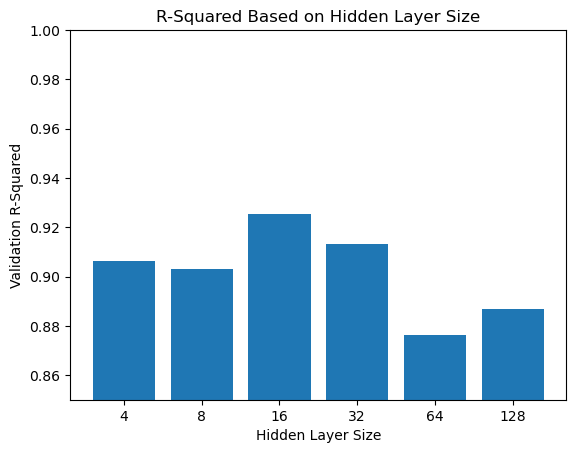

In [9]:
plt.bar([str(size) for size in sizes], r2_scores)
plt.ylim(0.85, 1.0) 
plt.xlabel('Hidden Layer Size')
plt.ylabel('Validation R-Squared')
plt.title('R-Squared Based on Hidden Layer Size')

Looking at the results above, we can see that choosing the right number of neurons is crucial when trying to achieve optimal performance. There certainly appears to be a trade-off between network size and performance in this case. If we choose less than 16 neurons, we can see from the validation performance that we are underfitting the training data and see sub-optimal performance on the validation set. On the other hand, if we make the network too large we run the risk of overfitting the training data. Furthermore, if we look at the training and validation loss plots, we can see that as we make the network larger, the validation loss curve becomes less stable which indicates overfitting during training. Overall, it appears that a hidden layer size of 16 is the best choice. 

# *Part 3: Neural Network Comparison - number of hidden layers*

In [10]:
def create_nn(num_layers):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    for i in range(1, num_layers + 1):
        model.add(Dense(16))
        model.add(Activation('sigmoid'))
    model.add(Dense(1))
    model.add(Activation('linear'))

    model.compile(loss='mse', optimizer='adam', metrics=['mse'])
    history = model.fit(X_train, y_train, batch_size=64, epochs=50, validation_data=(X_test, y_test), verbose=0)

    test_pred = model.predict(X_test)
    test_r2 = r2_score(y_test, test_pred)
    
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.legend()
    plt.show()

    return test_r2

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


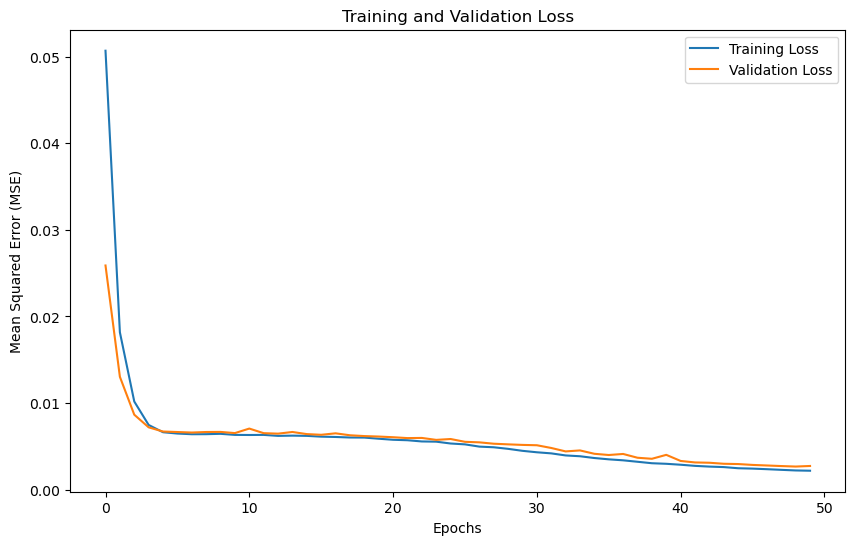

Validation R-Squared (Number of Hidden Layers: 1): 0.906011706869674
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


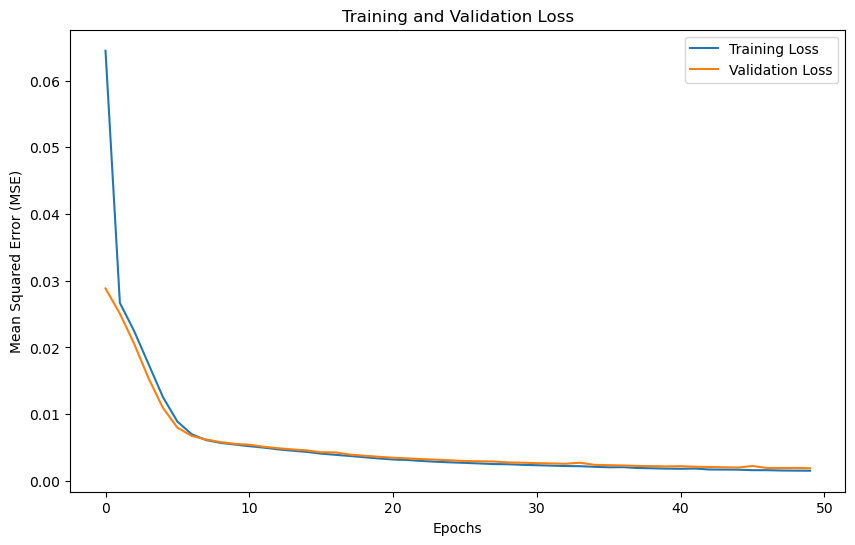

Validation R-Squared (Number of Hidden Layers: 2): 0.9350424982813295
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


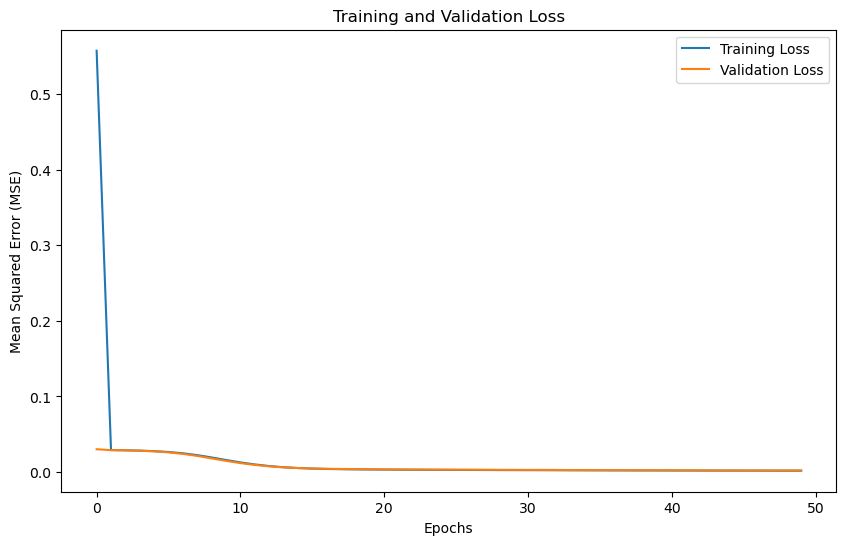

Validation R-Squared (Number of Hidden Layers: 3): 0.9295773327867091
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


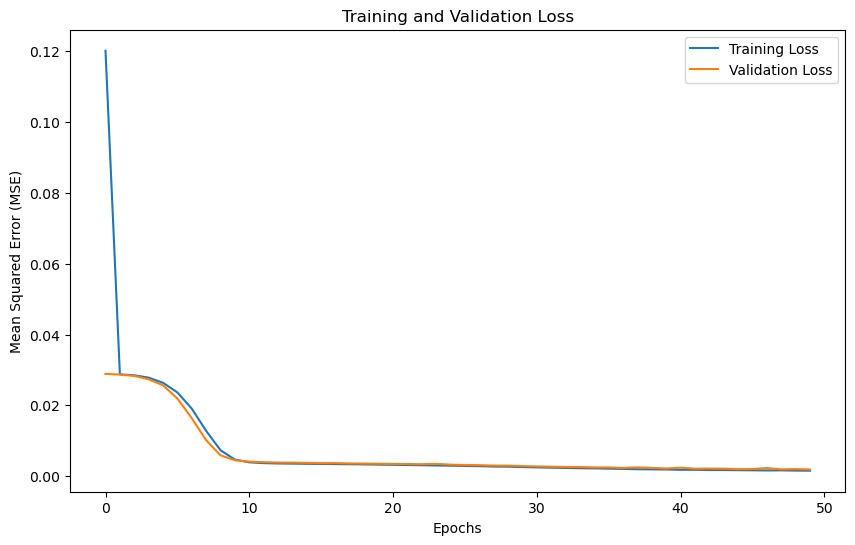

Validation R-Squared (Number of Hidden Layers: 4): 0.934640417362719
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


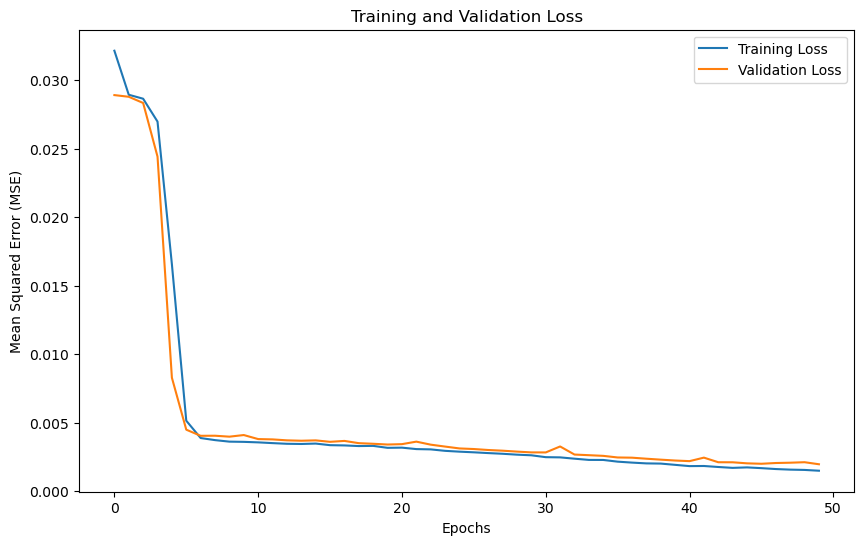

Validation R-Squared (Number of Hidden Layers: 5): 0.9319979301007526
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


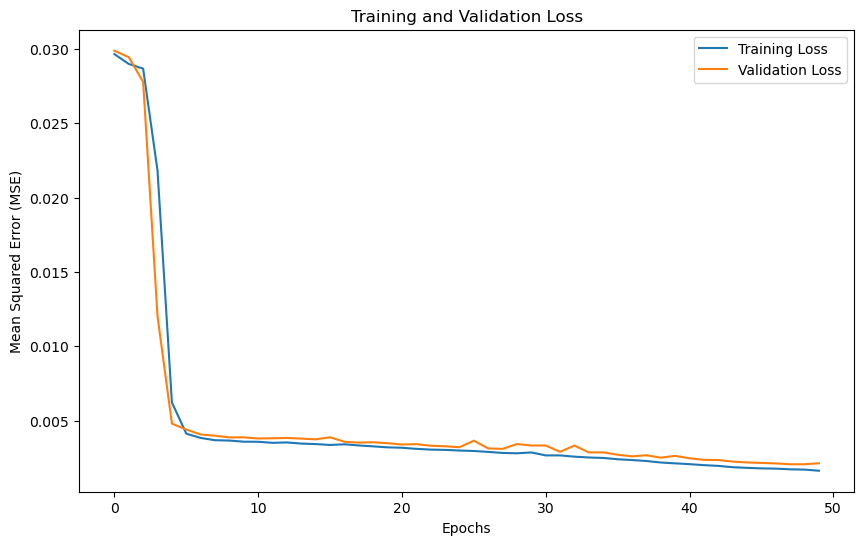

Validation R-Squared (Number of Hidden Layers: 6): 0.9261772502651427
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


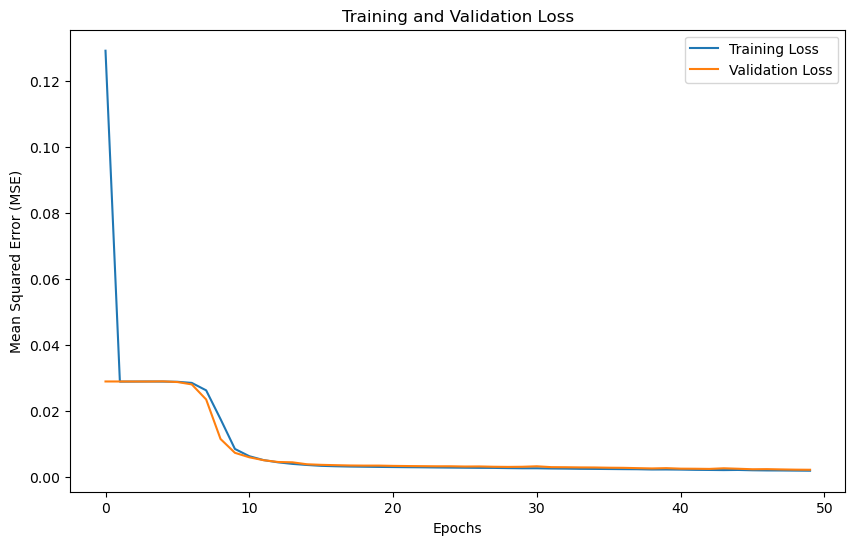

Validation R-Squared (Number of Hidden Layers: 7): 0.9234864302946839
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


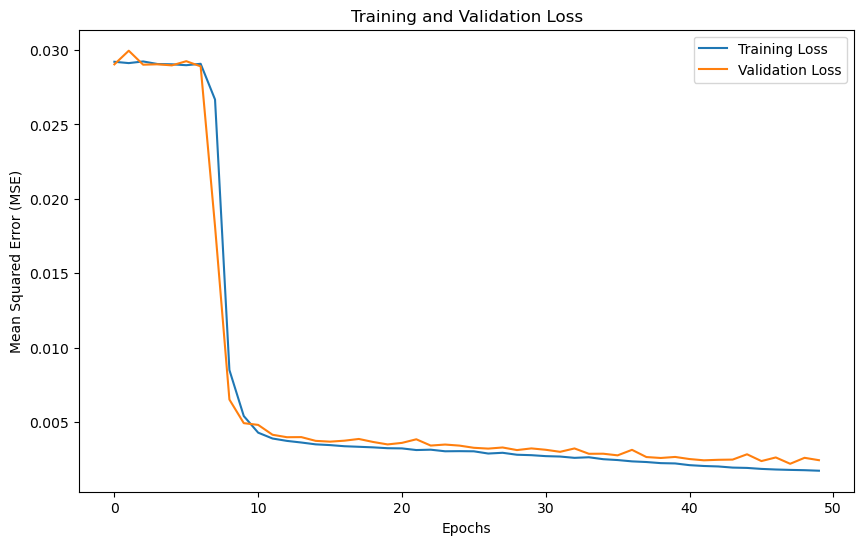

Validation R-Squared (Number of Hidden Layers: 8): 0.9160843685949845
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


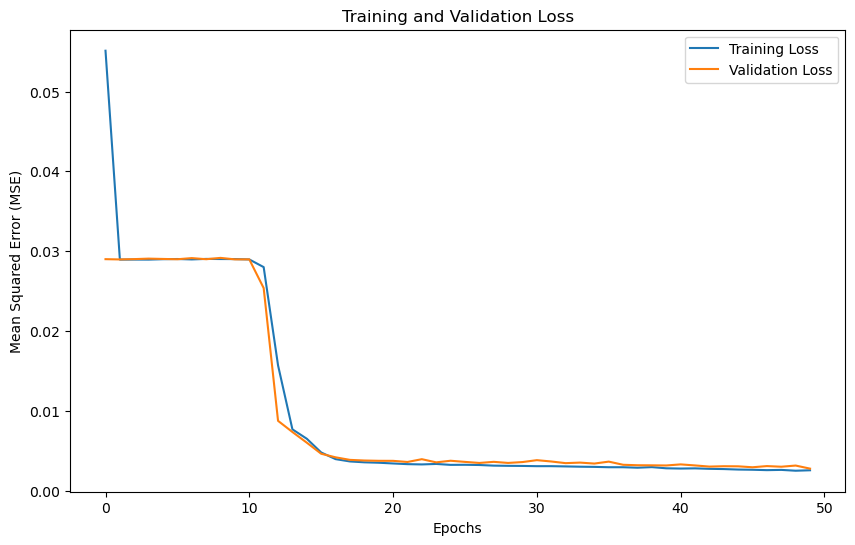

Validation R-Squared (Number of Hidden Layers: 9): 0.9047826608115705
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


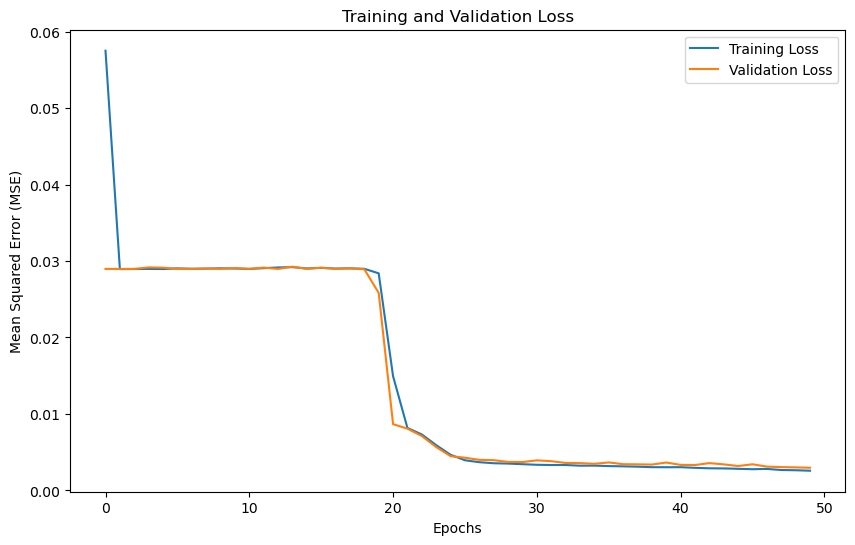

Validation R-Squared (Number of Hidden Layers: 10): 0.8978353301009446


In [13]:
layers = np.arange(1, 11)
r2_scores = []
for num_layers in layers:
    config_r2 = create_nn(num_layers)
    print(f'Validation R-Squared (Number of Hidden Layers: {num_layers}):', config_r2)
    r2_scores.append(config_r2)

Text(0.5, 1.0, 'R-Squared Based on Number of Hidden Layers')

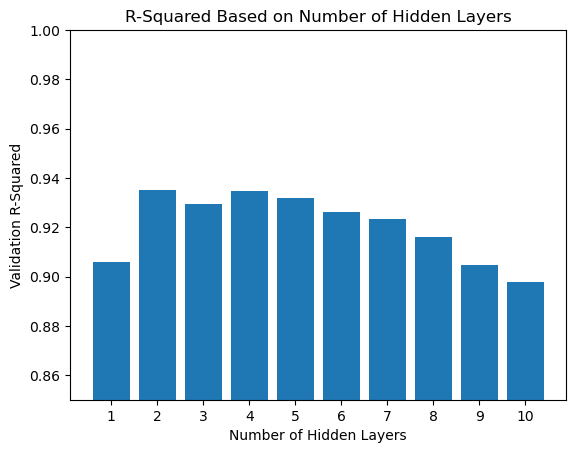

In [14]:
plt.bar([str(num) for num in layers], r2_scores)
plt.ylim(0.85, 1.0) 
plt.xlabel('Number of Hidden Layers')
plt.ylabel('Validation R-Squared')
plt.title('R-Squared Based on Number of Hidden Layers')

The results above show that the number of hidden layers plays a significant role in overall model performance. Similar to choosing the number of neurons within each hidden layer, choosing the best number of hidden layers also seems to come with trade-offs. If we choose a model that is too shallow, we run the risk of underfitting the training data and having a network that is not flexible enough to achieve the best performance. On the other hand, we can see that if we make the network too deep we can overfit the training data and again get sub-optimal performance. We can see that performance on both ends of the barplot are not optimal due to these underfitting and overfitting cases. This shows that a deeper and more complex network does not always lead to better generalization on the validation set. Overall, when comparing sheer performance we can see that the optimal number of hidden layers is 2. However, it is important to note that after running this procedure several times I got different results and thus there is a degree of randomness in this process of determining the optimal network structure. 

# *Part 4: Neural Network Comparison - Effect of batch size*

In [15]:
def evaluate_batches(batch_size):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(16))
    model.add(Activation('sigmoid'))
    model.add(Dense(16))
    model.add(Activation('sigmoid'))
    model.add(Dense(1))
    model.add(Activation('linear'))

    model.compile(loss='mse', optimizer='adam', metrics=['mse'])
    start_time = time.time()
    history = model.fit(X_train, y_train, batch_size=batch_size, epochs=50, validation_data=(X_test, y_test), verbose=0)
    end_time = time.time()

    test_pred = model.predict(X_test)
    test_r2 = r2_score(y_test, test_pred)
    
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.legend()
    plt.show()

    training_time = end_time - start_time
    return test_r2, training_time

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


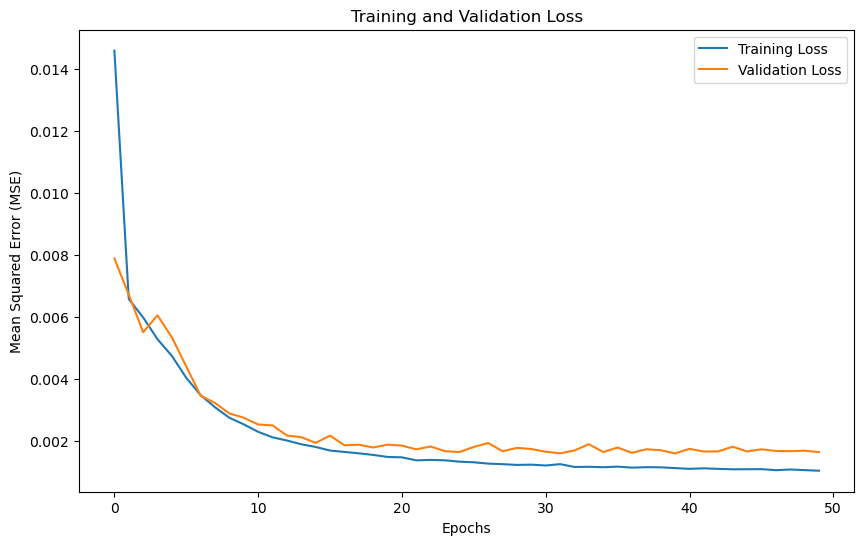

Validation R-Squared (Batch Size: 8): 0.9429357548007624
Training Time (Batch Size: 8): 38.6021728515625
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


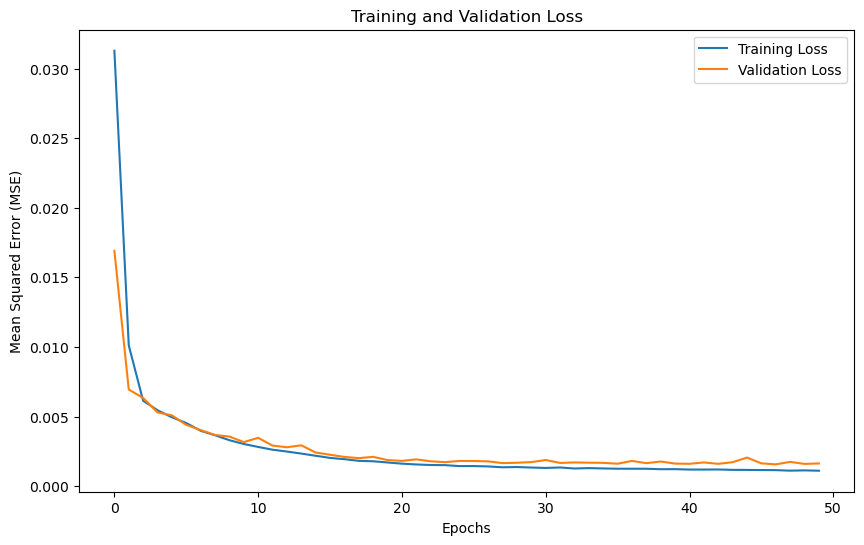

Validation R-Squared (Batch Size: 16): 0.9437308079688107
Training Time (Batch Size: 16): 21.59144949913025
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


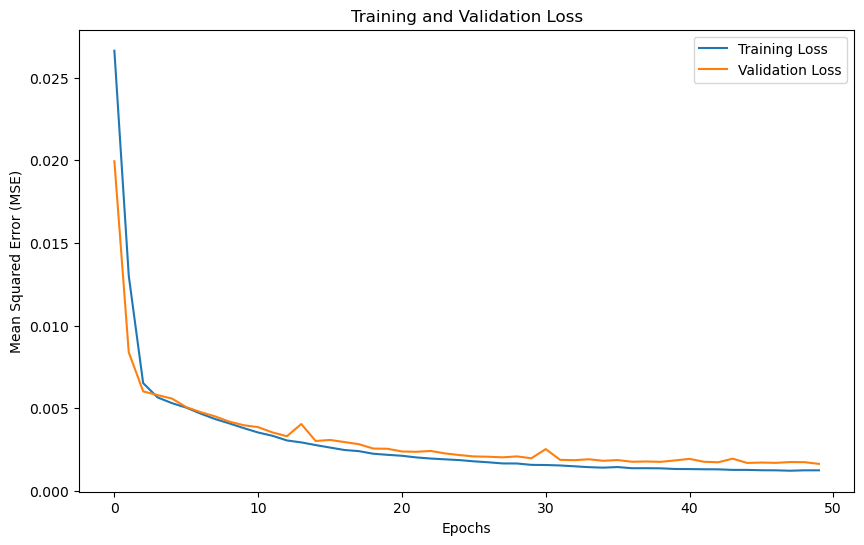

Validation R-Squared (Batch Size: 32): 0.9435484614856336
Training Time (Batch Size: 32): 12.575313091278076
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


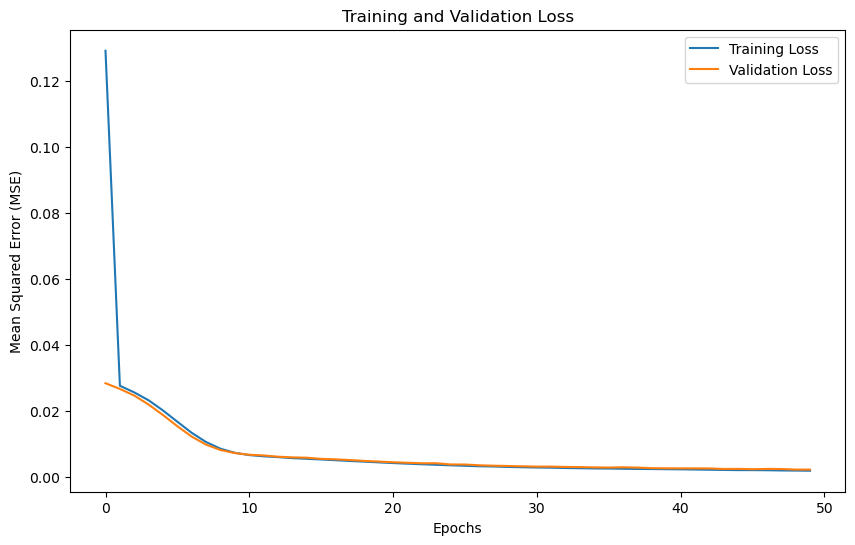

Validation R-Squared (Batch Size: 64): 0.9262613008252532
Training Time (Batch Size: 64): 8.242281436920166
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


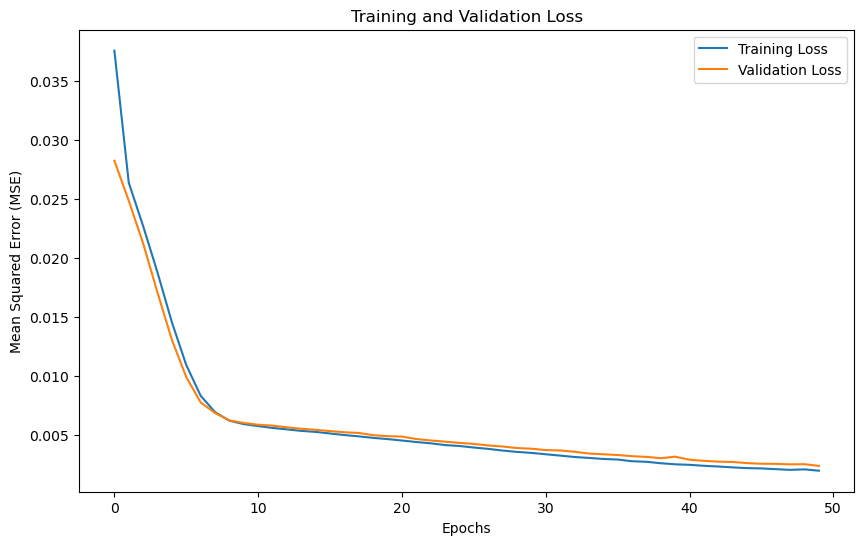

Validation R-Squared (Batch Size: 128): 0.9167609993545133
Training Time (Batch Size: 128): 5.847934722900391


In [16]:
batch_sizes = [8, 16, 32, 64, 128]
r2_scores = []
training_times = []
for batch_size in batch_sizes:
    config_r2, config_training_time = evaluate_batches(batch_size)
    r2_scores.append(config_r2)
    training_times.append(config_training_time)
    print(f'Validation R-Squared (Batch Size: {batch_size}):', config_r2)
    print(f'Training Time (Batch Size: {batch_size}):', config_training_time)    

Text(0.5, 1.0, 'Validation R-Squared Based on Batch Size')

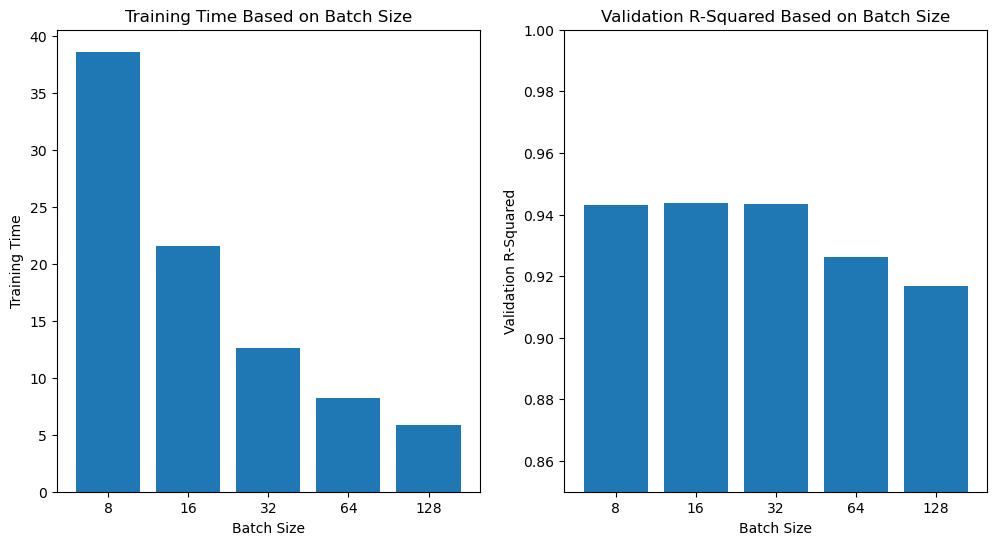

In [17]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

axes[0].bar([str(size) for size in batch_sizes], training_times)
axes[0].set_xlabel('Batch Size')
axes[0].set_ylabel('Training Time')
axes[0].set_title('Training Time Based on Batch Size')

axes[1].bar([str(size) for size in batch_sizes], r2_scores)
axes[1].set_ylim(0.85, 1.0) 
axes[1].set_xlabel('Batch Size')
axes[1].set_ylabel('Validation R-Squared')
axes[1].set_title('Validation R-Squared Based on Batch Size')

We can see from the bar plots above that batch size has a clear impact on the training speed. By increasing the batch time, we can make training much more efficient which is certainly something to consider especially if working with high-dimensional data. However, there seems to be a tradeoff between training time and performance when looking at the plots above. As we increase the batch size, we see significantly faster training, however, this comes at the cost of performance which gets slightly worse as we increase the batch size. Also, when looking at the plots for each different batch size we can see that as we increase the batch size we get more training stability and smoother model convergence. This is because we are allowing the network to perform gradient descent after calculating loss on more training samples which leads to less variability in the gradient descent algorithm. On the other hand, with a smaller batch size we have lower training efficiency and stability, but we can preserve slightly more performance than when using a larger batch size. Overall, when looking at the results it appears that the optimal batch size is 16 in terms of sheer performance. However, similar to determining the optimal number of hidden layers, there is a degree of randomness to this procedure as I got different results for each run. This is important to note when searching for the optimal neural network configuration. 

# *Part 5: Comparison with Linear Regression*

In [18]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lr = lin_reg.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)

optimal_nn = Sequential()
optimal_nn.add(Input(shape=(X_train.shape[1],)))
optimal_nn.add(Dense(16))
optimal_nn.add(Activation('sigmoid'))
optimal_nn.add(Dense(16))
optimal_nn.add(Activation('sigmoid'))
optimal_nn.add(Dense(1))
optimal_nn.add(Activation('linear'))

optimal_nn.compile(loss='mse', optimizer='adam', metrics=['mse'])
history = optimal_nn.fit(X_train, y_train, batch_size=16, epochs=50, verbose=0)

y_pred_nn = optimal_nn.predict(X_test)
r2_nn = r2_score(y_test, y_pred_nn)
mse_nn = mean_squared_error(y_test, y_pred_nn)

results_df = pd.DataFrame({'R-Squared': [r2_lr, r2_nn], 'Mean Squared Error': [mse_lr, mse_nn]}, index=['Baseline Linear Regression', 'Optimal Neural Network'])
results_df

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,R-Squared,Mean Squared Error
Baseline Linear Regression,0.777906,0.006433
Optimal Neural Network,0.943412,0.001639


Comparing these two models, we can see that the optimal neural network performs significantly better than the baseline linear regression in terms of both r-squared and mean squared error. The neural network performs better than the linear regression likely because it is a much more complex model that is able to capture more nuanced and non-linear relationships within the training data. On the other hand, the simple linear regression is much more rigid and only able to model linear relationships. Thus, the extra flexibility of the neural network allows it to fit the training data much better without overfitting which leads to much better performance on the validation set as we can see above. I also want to note that I got different results on each run of this notebook and the metrics seen above can change, however the neural network is clearly a better performing model in this case. 